In [1]:
!pip install astropy

In [2]:
import pandas as pd
from astropy.coordinates import SkyCoord
from astropy import units as u
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.stats import linregress

### Datos Surveys

In [3]:
#Ruta completa a los archivos
path = '/mnt/c/Users/Leire/Downloads/'
des_file = path + 'des.csv'
desi_file = path + 'xmatch_astrogeo_desi.csv'

In [4]:
#Cargar los catálogos
des = pd.read_csv(des_file)
desi = pd.read_csv(desi_file)

In [5]:
#Verificar si hay NaNs en RA y DEC
print("DES: NaNs en RA:", des['Astrogeo_DES_full_catalogue_matches_good_RA'].isna().sum())
print("DES: NaNs en DEC:", des['Astrogeo_DES_full_catalogue_matches_good_DEC'].isna().sum())

print("DESI: NaNs en RA:", desi['RA_1'].isna().sum())
print("DESI: NaNs en DEC:", desi['DEC_1'].isna().sum())

DES: NaNs en RA: 0
DES: NaNs en DEC: 0
DESI: NaNs en RA: 0
DESI: NaNs en DEC: 0


In [6]:
#Cargamos también los catálogos filtrados
des_1 = des[(des['DES_full_catalogue_Astrogeo_EXTENDED_CLASS_COADD_matches'].isin([2, 3]))]
desi_1 = desi[(desi['TYPE'].isin(['EXP', 'DEV', 'SER']))]

In [7]:
#Creamos objetos en SkyCoord

#DES
coords_des = SkyCoord(ra=des['Astrogeo_DES_full_catalogue_matches_good_RA'].values*u.degree,
                      dec=des['Astrogeo_DES_full_catalogue_matches_good_DEC'].values*u.degree)

coords_des_1 = SkyCoord(ra=des_1['Astrogeo_DES_full_catalogue_matches_good_RA'].values*u.degree,
                      dec=des_1['Astrogeo_DES_full_catalogue_matches_good_DEC'].values*u.degree)

#DESI
coords_desi = SkyCoord(ra=desi['RA_1'].values*u.degree, dec=desi['DEC_1'].values*u.degree)

coords_desi_1 = SkyCoord(ra=desi_1['RA_1'].values*u.degree, dec=desi_1['DEC_1'].values*u.degree)

Ahora vamos a proceder a hacer los cross-matches. En primer lugar, vamos a realizar un cross-match con los datos sin filtrar. Luego, con uno de los surveys filtrados y el otro sin filtrar, y viceversa.  Por último, vamos a realizar un cross-match con los datos de ambos surveys filtrados.

### X-MATCH DES-DESI

##### DES y DESI sin filtrar

In [8]:
#Hacemos el crossmatch con un radio máximo
idx, d2d, _ = coords_des.match_to_catalog_sky(coords_desi)
max_sep = 1.0*u.arcsec
mask = d2d < max_sep

#Extraemos los datos que coinciden
des_matched_0 = des[mask].reset_index(drop=True)
desi_matched_0 = desi.iloc[idx[mask]].reset_index(drop=True)

#Combinamos los resultados en un solo DataFrame
crossmatched_des_desi_0 = pd.concat([des_matched_0, desi_matched_0], axis=1)

#Guardamos el resultado en CSV
crossmatched_des_desi_0.to_csv(path + 'DES_DESI_crossmatched_0.csv', index=False)
print(f"Crossmatch finalizado: {len(crossmatched_des_desi_0)} objetos encontrados.")

Crossmatch finalizado: 741 objetos encontrados.


##### DES filtrado y DESI sin filtrar

In [9]:
#Hacemos el crossmatch con un radio máximo
idx, d2d, _ = coords_des_1.match_to_catalog_sky(coords_desi)
max_sep = 1.0*u.arcsec
mask = d2d < max_sep

#Extraemos los datos que coinciden
des_matched_1 = des_1[mask].reset_index(drop=True)
desi_matched_0 = desi.iloc[idx[mask]].reset_index(drop=True)

#Combinamos los resultados en un solo DataFrame
crossmatched_des_desi_1 = pd.concat([des_matched_1, desi_matched_0], axis=1)

#Guardamos el resultado en CSV
crossmatched_des_desi_1.to_csv(path + 'DES_DESI_crossmatched_1.csv', index=False)
print(f"Crossmatch finalizado: {len(crossmatched_des_desi_1)} objetos encontrados.")

Crossmatch finalizado: 261 objetos encontrados.


##### DES sin filtrar y DESI filtrado

In [10]:
#Hacemos el crossmatch con un radio máximo
idx, d2d, _ = coords_des.match_to_catalog_sky(coords_desi_1)
max_sep = 1.0*u.arcsec
mask = d2d < max_sep

#Extraemos los datos que coinciden
des_matched_0 = des[mask].reset_index(drop=True)
desi_matched_1 = desi_1.iloc[idx[mask]].reset_index(drop=True)

#Combinamos los resultados en un solo DataFrame
crossmatched_des_desi_2 = pd.concat([des_matched_0, desi_matched_1], axis=1)

#Guardamos el resultado en CSV
crossmatched_des_desi_2.to_csv(path + 'DES_DESI_crossmatched_2.csv', index=False)
print(f"Crossmatch finalizado: {len(crossmatched_des_desi_2)} objetos encontrados.")

Crossmatch finalizado: 146 objetos encontrados.


##### DES y DESI filtrados

In [11]:
#Hacemos el crossmatch con un radio máximo
idx, d2d, _ = coords_des_1.match_to_catalog_sky(coords_desi_1)
max_sep = 1.0*u.arcsec
mask = d2d < max_sep

#Extraemos los datos que coinciden
des_matched_1 = des_1[mask].reset_index(drop=True)
desi_matched_1 = desi_1.iloc[idx[mask]].reset_index(drop=True)

#Combinamos los resultados en un solo DataFrame
crossmatched_des_desi_3 = pd.concat([des_matched_1, desi_matched_1], axis=1)

#Guardamos el resultado en CSV
crossmatched_des_desi_3.to_csv(path + 'DES_DESI_crossmatched_3.csv', index=False)
print(f"Crossmatch finalizado: {len(crossmatched_des_desi_3)} objetos encontrados.")

Crossmatch finalizado: 137 objetos encontrados.


### ESTUDIO DE RA Y DEC

#### RA DES VS RA DESI

##### RA DES (sin filtrar) VS RA DESI (sin filtrar)

Regresión lineal: y = 1.0000*x + 0.0000
Coeficiente de correlación (r): 1.0000
Error estándar: 0.0000
p-valor: 0.0000e+00


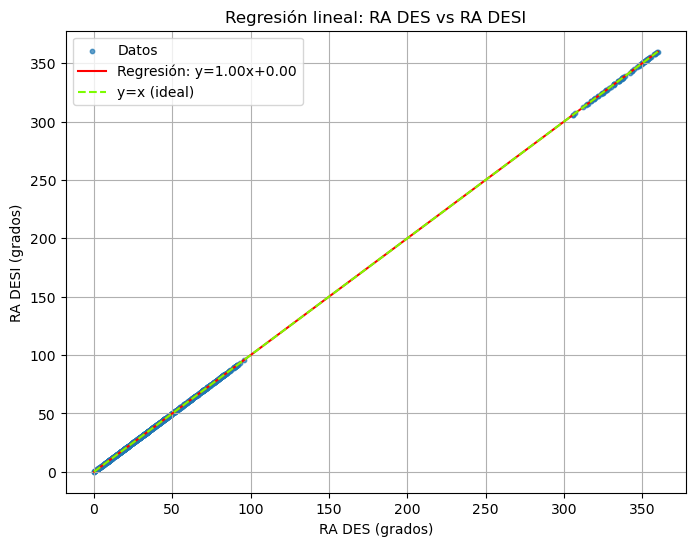

In [12]:
#Hacemos una regresión lineal para ver mejor la diferencia
x = crossmatched_des_desi_0['Astrogeo_DES_full_catalogue_matches_good_RA']
y = crossmatched_des_desi_0['RA_1']

#Ajuste lineal
slope, intercept, r_value, p_value, std_err = linregress(x, y)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos el scatter y la recta ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x, y, s=10, alpha=0.7, label='Datos')
plt.plot(x, slope * x + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')
plt.plot([min(x), max(x)], [min(x), max(x)], color='lawngreen', linestyle='--', label='y=x (ideal)')
plt.xlabel('RA DES (grados)')
plt.ylabel('RA DESI (grados)')
plt.title('Regresión lineal: RA DES vs RA DESI')
plt.grid(True)
plt.legend()
plt.show()

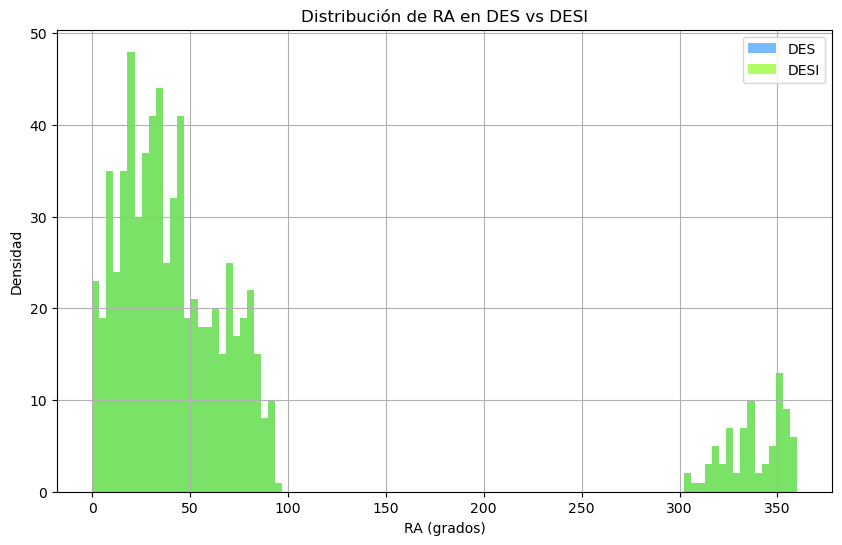

In [13]:
#Se puede hacer también un histograma de los RA
plt.figure(figsize=(10, 6))
plt.hist(crossmatched_des_desi_0['Astrogeo_DES_full_catalogue_matches_good_RA'], bins=100, color='dodgerblue', alpha=0.6, label='DES')
plt.hist(crossmatched_des_desi_0['RA_1'], bins=100, color='lawngreen', alpha=0.6, label='DESI')
plt.xlabel('RA (grados)')
plt.ylabel('Densidad')
plt.title('Distribución de RA en DES vs DESI')
plt.legend()
plt.grid(True)
plt.show()

##### RA DES (filtrado) VS RA DESI (sin filtrar)

Regresión lineal: y = 1.0000*x + 0.0000
Coeficiente de correlación (r): 1.0000
Error estándar: 0.0000
p-valor: 0.0000e+00


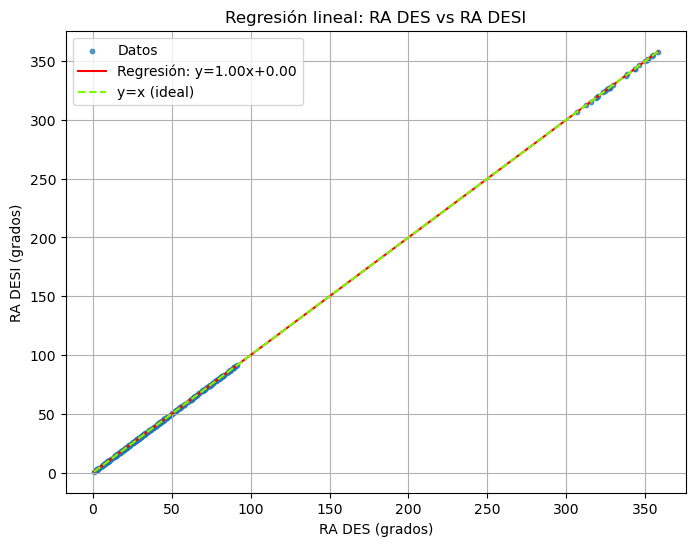

In [14]:
#Hacemos una regresión lineal para ver mejor la diferencia
x = crossmatched_des_desi_1['Astrogeo_DES_full_catalogue_matches_good_RA']
y = crossmatched_des_desi_1['RA_1']

#Ajuste lineal
slope, intercept, r_value, p_value, std_err = linregress(x, y)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos el scatter y la recta ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x, y, s=10, alpha=0.7, label='Datos')
plt.plot(x, slope * x + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')
plt.plot([min(x), max(x)], [min(x), max(x)], color='lawngreen', linestyle='--', label='y=x (ideal)')
plt.xlabel('RA DES (grados)')
plt.ylabel('RA DESI (grados)')
plt.title('Regresión lineal: RA DES vs RA DESI')
plt.grid(True)
plt.legend()
plt.show()

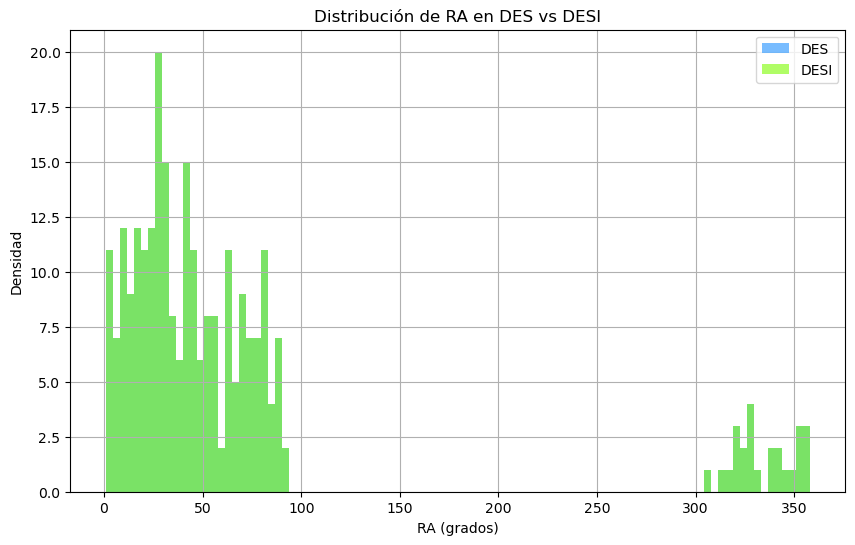

In [15]:
#Histograma de los RA
plt.figure(figsize=(10, 6))
plt.hist(crossmatched_des_desi_1['Astrogeo_DES_full_catalogue_matches_good_RA'], bins=100, color='dodgerblue', alpha=0.6, label='DES')
plt.hist(crossmatched_des_desi_1['RA_1'], bins=100, color='lawngreen', alpha=0.6, label='DESI')
plt.xlabel('RA (grados)')
plt.ylabel('Densidad')
plt.title('Distribución de RA en DES vs DESI')
plt.legend()
plt.grid(True)
plt.show()

##### RA DES (sin filtrar) VS RA DESI (filtrado)

Regresión lineal: y = 1.0000*x + 0.0000
Coeficiente de correlación (r): 1.0000
Error estándar: 0.0000
p-valor: 0.0000e+00


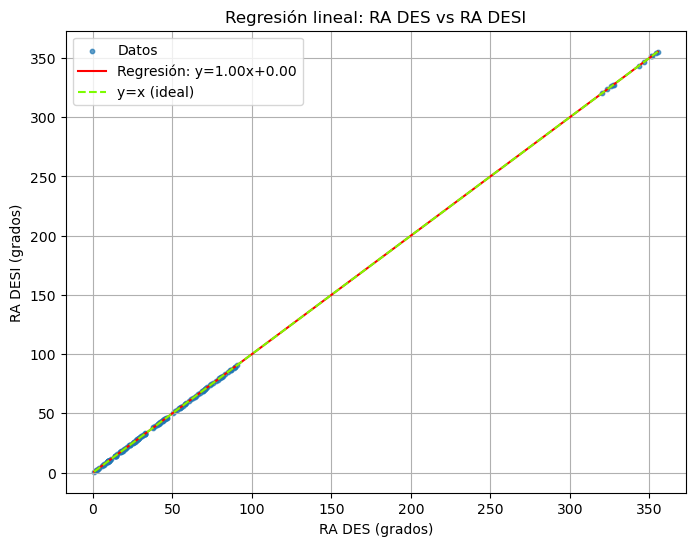

In [16]:
#Hacemos una regresión lineal para ver mejor la diferencia
x = crossmatched_des_desi_2['Astrogeo_DES_full_catalogue_matches_good_RA']
y = crossmatched_des_desi_2['RA_1']

#Ajuste lineal
slope, intercept, r_value, p_value, std_err = linregress(x, y)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos el scatter y la recta ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x, y, s=10, alpha=0.7, label='Datos')
plt.plot(x, slope * x + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')
plt.plot([min(x), max(x)], [min(x), max(x)], color='lawngreen', linestyle='--', label='y=x (ideal)')
plt.xlabel('RA DES (grados)')
plt.ylabel('RA DESI (grados)')
plt.title('Regresión lineal: RA DES vs RA DESI')
plt.grid(True)
plt.legend()
plt.show()

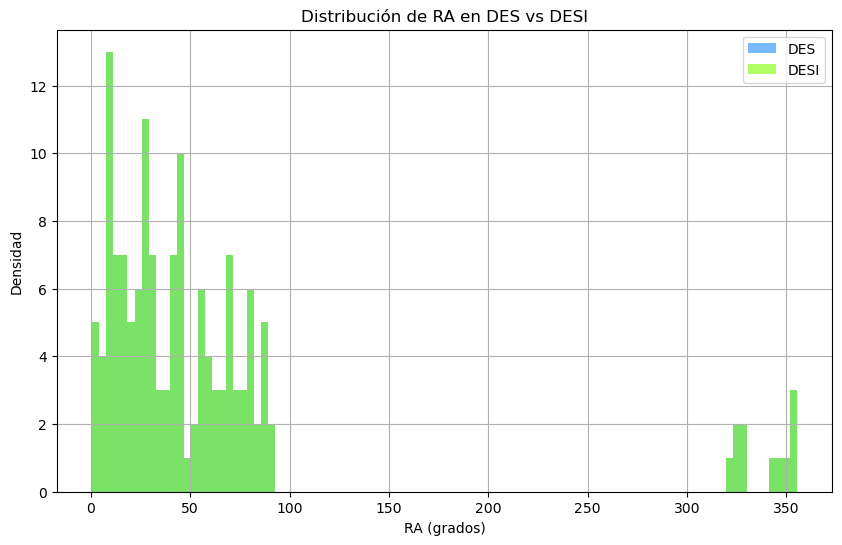

In [17]:
#Histograma de los RA
plt.figure(figsize=(10, 6))
plt.hist(crossmatched_des_desi_2['Astrogeo_DES_full_catalogue_matches_good_RA'], bins=100, color='dodgerblue', alpha=0.6, label='DES')
plt.hist(crossmatched_des_desi_2['RA_1'], bins=100, color='lawngreen', alpha=0.6, label='DESI')
plt.xlabel('RA (grados)')
plt.ylabel('Densidad')
plt.title('Distribución de RA en DES vs DESI')
plt.legend()
plt.grid(True)
plt.show()

##### RA DES (filtrado) VS RA DESI (filtrado)

Regresión lineal: y = 1.0000*x + 0.0000
Coeficiente de correlación (r): 1.0000
Error estándar: 0.0000
p-valor: 0.0000e+00


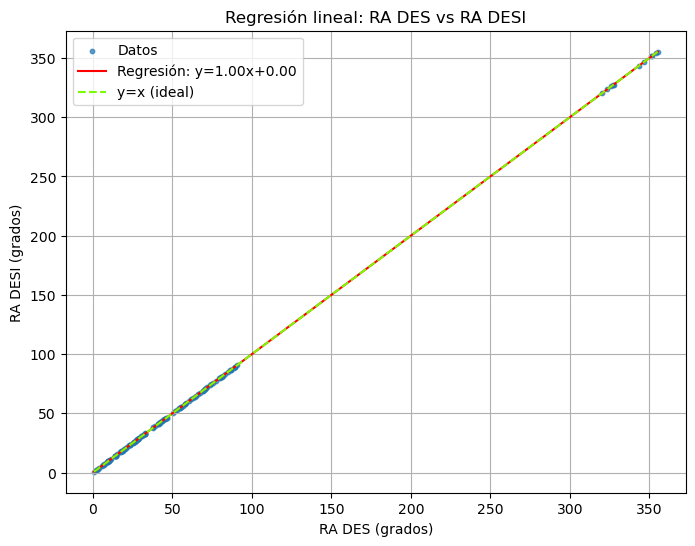

In [18]:
#Hacemos una regresión lineal para ver mejor la diferencia
x = crossmatched_des_desi_3['Astrogeo_DES_full_catalogue_matches_good_RA']
y = crossmatched_des_desi_3['RA_1']

#Ajuste lineal
slope, intercept, r_value, p_value, std_err = linregress(x, y)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos el scatter y la recta ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x, y, s=10, alpha=0.7, label='Datos')
plt.plot(x, slope * x + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')
plt.plot([min(x), max(x)], [min(x), max(x)], color='lawngreen', linestyle='--', label='y=x (ideal)')
plt.xlabel('RA DES (grados)')
plt.ylabel('RA DESI (grados)')
plt.title('Regresión lineal: RA DES vs RA DESI')
plt.grid(True)
plt.legend()
plt.show()

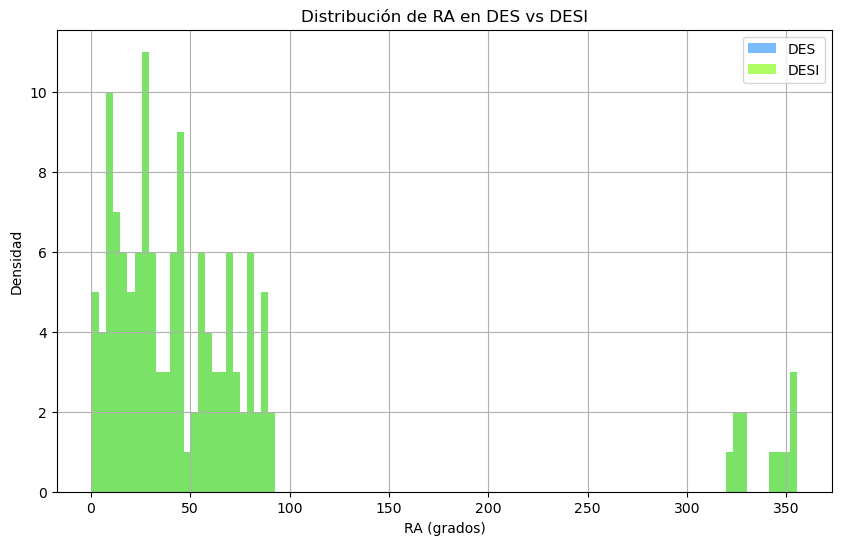

In [19]:
#Histograma de los RA
plt.figure(figsize=(10, 6))
plt.hist(crossmatched_des_desi_3['Astrogeo_DES_full_catalogue_matches_good_RA'], bins=100, color='dodgerblue', alpha=0.6, label='DES')
plt.hist(crossmatched_des_desi_3['RA_1'], bins=100, color='lawngreen', alpha=0.6, label='DESI')
plt.xlabel('RA (grados)')
plt.ylabel('Densidad')
plt.title('Distribución de RA en DES vs DESI')
plt.legend()
plt.grid(True)
plt.show()

#### DEC DES VS DESI

##### DEC DES (sin filtrar) VS DEC DESI (sin filtrar)

Regresión lineal: y = 1.0000*x + 0.0000
Coeficiente de correlación (r): 1.0000
Error estándar: 0.0000
p-valor: 0.0000e+00


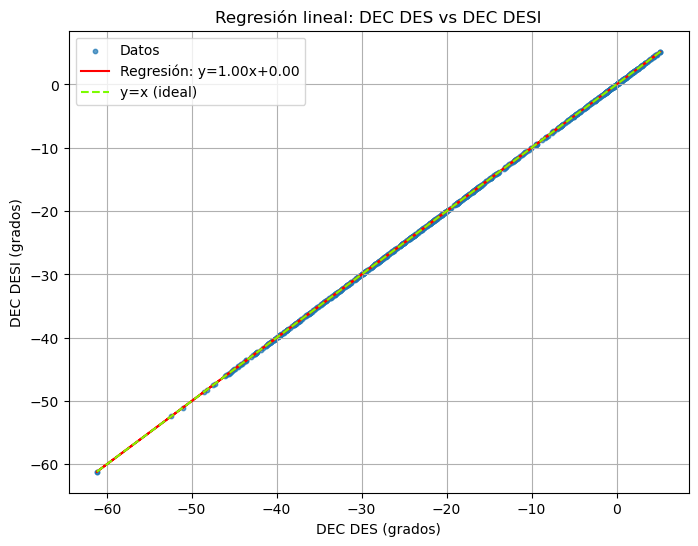

In [20]:
#Hacemos una regresión lineal para ver mejor la diferencia
x = crossmatched_des_desi_0['Astrogeo_DES_full_catalogue_matches_good_DEC']
y = crossmatched_des_desi_0['DEC_1']

#Ajuste lineal
slope, intercept, r_value, p_value, std_err = linregress(x, y)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos el scatter y la recta ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x, y, s=10, alpha=0.7, label='Datos')
plt.plot(x, slope * x + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')
plt.plot([min(x), max(x)], [min(x), max(x)], color='lawngreen', linestyle='--', label='y=x (ideal)')
plt.xlabel('DEC DES (grados)')
plt.ylabel('DEC DESI (grados)')
plt.title('Regresión lineal: DEC DES vs DEC DESI')
plt.grid(True)
plt.legend()
plt.show()

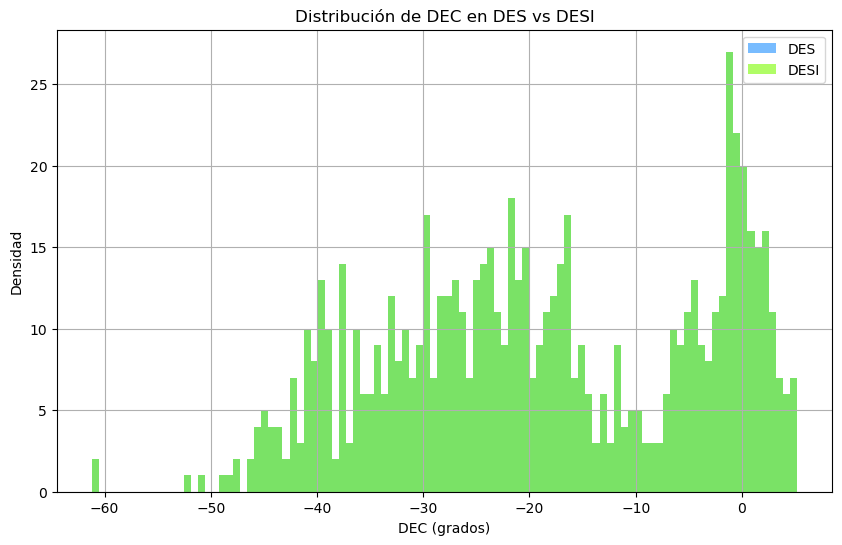

In [21]:
#Histograma de los DEC
plt.figure(figsize=(10, 6))
plt.hist(crossmatched_des_desi_0['Astrogeo_DES_full_catalogue_matches_good_DEC'], bins=100, color='dodgerblue', alpha=0.6, label='DES')
plt.hist(crossmatched_des_desi_0['DEC_1'], bins=100, color='lawngreen', alpha=0.6, label='DESI')
plt.xlabel('DEC (grados)')
plt.ylabel('Densidad')
plt.title('Distribución de DEC en DES vs DESI')
plt.legend()
plt.grid(True)
plt.show()

##### DEC DES (filtrado) VS DEC DESI (sin filtrar)

Regresión lineal: y = 1.0000*x + 0.0000
Coeficiente de correlación (r): 1.0000
Error estándar: 0.0000
p-valor: 0.0000e+00


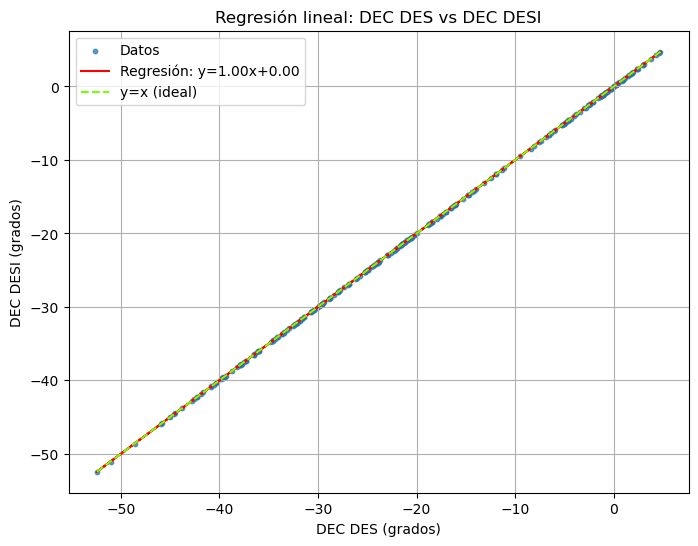

In [22]:
#Hacemos una regresión lineal para ver mejor la diferencia
x = crossmatched_des_desi_1['Astrogeo_DES_full_catalogue_matches_good_DEC']
y = crossmatched_des_desi_1['DEC_1']

#Ajuste lineal
slope, intercept, r_value, p_value, std_err = linregress(x, y)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos el scatter y la recta ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x, y, s=10, alpha=0.7, label='Datos')
plt.plot(x, slope * x + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')
plt.plot([min(x), max(x)], [min(x), max(x)], color='lawngreen', linestyle='--', label='y=x (ideal)')
plt.xlabel('DEC DES (grados)')
plt.ylabel('DEC DESI (grados)')
plt.title('Regresión lineal: DEC DES vs DEC DESI')
plt.grid(True)
plt.legend()
plt.show()

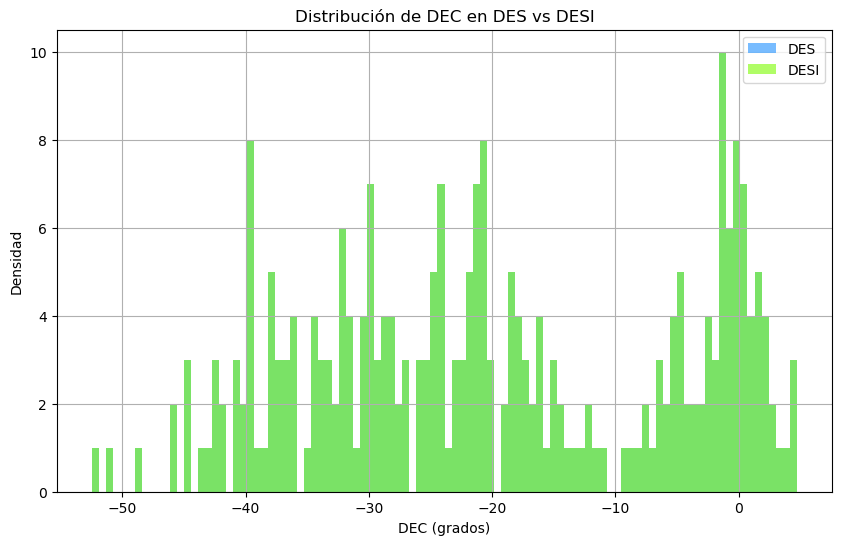

In [23]:
#Histograma de los DEC
plt.figure(figsize=(10, 6))
plt.hist(crossmatched_des_desi_1['Astrogeo_DES_full_catalogue_matches_good_DEC'], bins=100, color='dodgerblue', alpha=0.6, label='DES')
plt.hist(crossmatched_des_desi_1['DEC_1'], bins=100, color='lawngreen', alpha=0.6, label='DESI')
plt.xlabel('DEC (grados)')
plt.ylabel('Densidad')
plt.title('Distribución de DEC en DES vs DESI')
plt.legend()
plt.grid(True)
plt.show()

##### DEC DES (sin filtrar) VS DEC DESI (filtrado)

Regresión lineal: y = 1.0000*x + 0.0000
Coeficiente de correlación (r): 1.0000
Error estándar: 0.0000
p-valor: 0.0000e+00


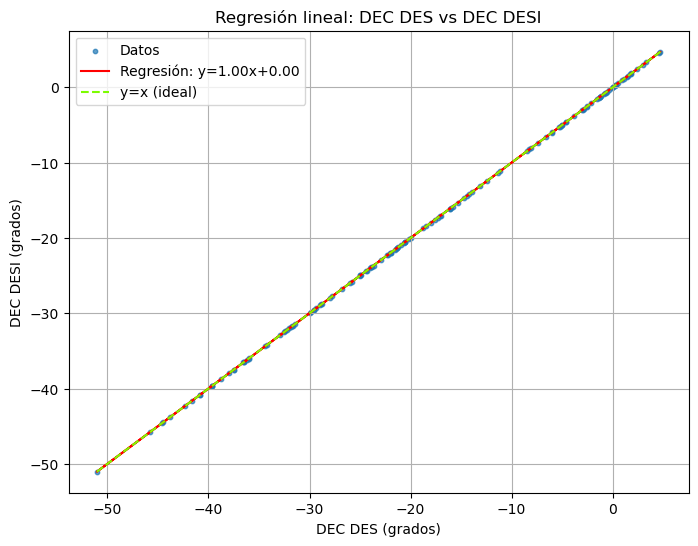

In [24]:
#Hacemos una regresión lineal para ver mejor la diferencia
x = crossmatched_des_desi_2['Astrogeo_DES_full_catalogue_matches_good_DEC']
y = crossmatched_des_desi_2['DEC_1']

#Ajuste lineal
slope, intercept, r_value, p_value, std_err = linregress(x, y)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos el scatter y la recta ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x, y, s=10, alpha=0.7, label='Datos')
plt.plot(x, slope * x + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')
plt.plot([min(x), max(x)], [min(x), max(x)], color='lawngreen', linestyle='--', label='y=x (ideal)')
plt.xlabel('DEC DES (grados)')
plt.ylabel('DEC DESI (grados)')
plt.title('Regresión lineal: DEC DES vs DEC DESI')
plt.grid(True)
plt.legend()
plt.show()

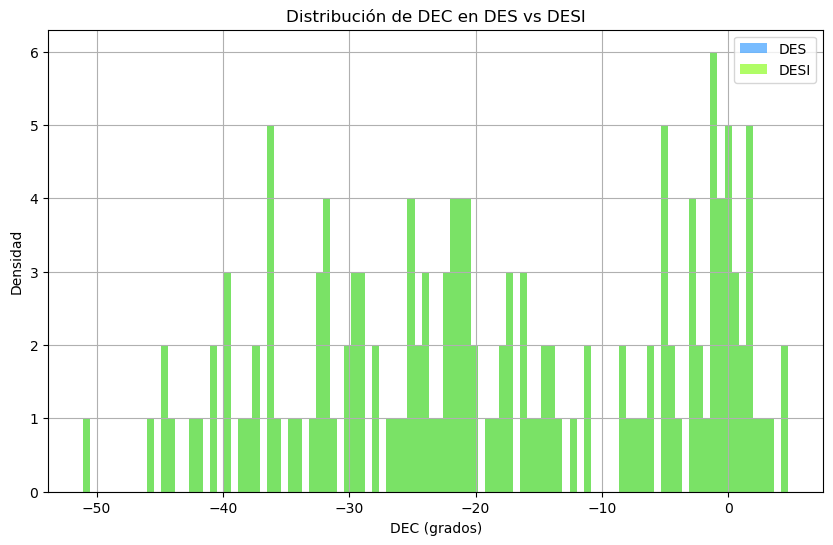

In [25]:
#Histograma de los DEC
plt.figure(figsize=(10, 6))
plt.hist(crossmatched_des_desi_2['Astrogeo_DES_full_catalogue_matches_good_DEC'], bins=100, color='dodgerblue', alpha=0.6, label='DES')
plt.hist(crossmatched_des_desi_2['DEC_1'], bins=100, color='lawngreen', alpha=0.6, label='DESI')
plt.xlabel('DEC (grados)')
plt.ylabel('Densidad')
plt.title('Distribución de DEC en DES vs DESI')
plt.legend()
plt.grid(True)
plt.show()

##### DEC DES (filtrado) VS DEC DESI (filtrado)

Regresión lineal: y = 1.0000*x + 0.0000
Coeficiente de correlación (r): 1.0000
Error estándar: 0.0000
p-valor: 0.0000e+00


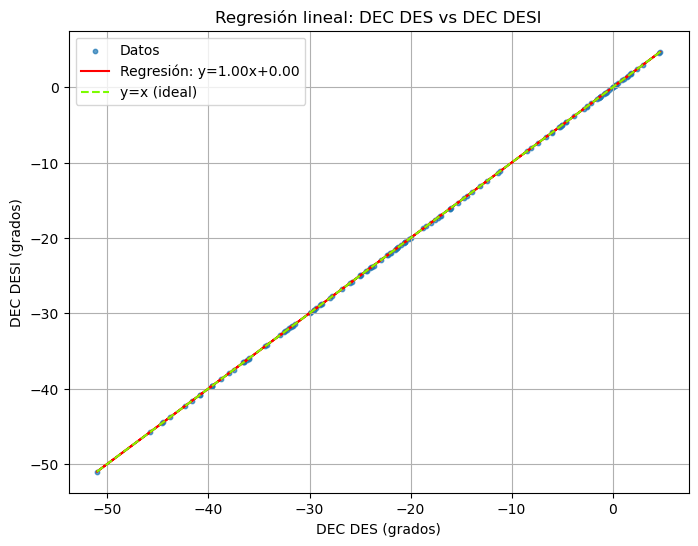

In [26]:
#Hacemos una regresión lineal para ver mejor la diferencia
x = crossmatched_des_desi_3['Astrogeo_DES_full_catalogue_matches_good_DEC']
y = crossmatched_des_desi_3['DEC_1']

#Ajuste lineal
slope, intercept, r_value, p_value, std_err = linregress(x, y)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos el scatter y la recta ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x, y, s=10, alpha=0.7, label='Datos')
plt.plot(x, slope * x + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')
plt.plot([min(x), max(x)], [min(x), max(x)], color='lawngreen', linestyle='--', label='y=x (ideal)')
plt.xlabel('DEC DES (grados)')
plt.ylabel('DEC DESI (grados)')
plt.title('Regresión lineal: DEC DES vs DEC DESI')
plt.grid(True)
plt.legend()
plt.show()

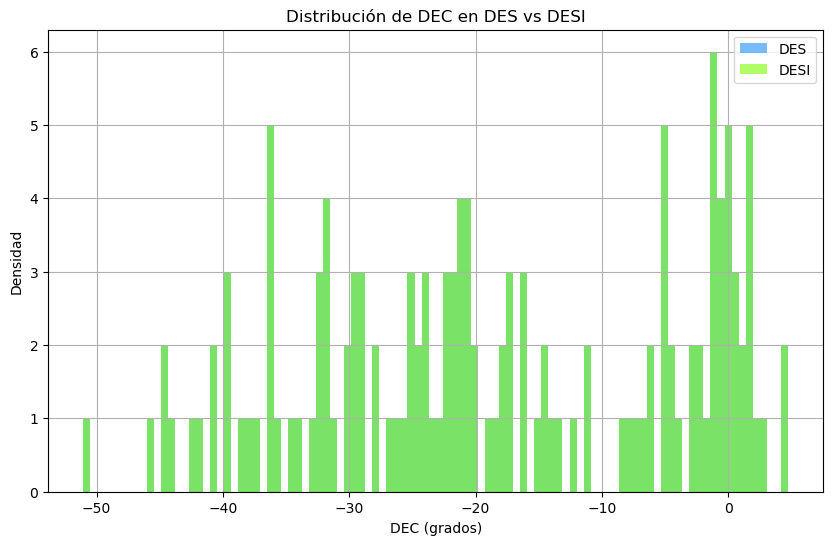

In [27]:
#Histograma de los DEC
plt.figure(figsize=(10, 6))
plt.hist(crossmatched_des_desi_3['Astrogeo_DES_full_catalogue_matches_good_DEC'], bins=100, color='dodgerblue', alpha=0.6, label='DES')
plt.hist(crossmatched_des_desi_3['DEC_1'], bins=100, color='lawngreen', alpha=0.6, label='DESI')
plt.xlabel('DEC (grados)')
plt.ylabel('Densidad')
plt.title('Distribución de DEC en DES vs DESI')
plt.legend()
plt.grid(True)
plt.show()

### ESTUDIO DE LOS EJES MAYOR Y MENOR

Se ha visto que hay una diferencia entre los ejes de DES y DESI, esto se debe a que estas magnitudes tienen distintas unidades en cada uno de los surveys. Por un lado, DESI utiliza arcosegundos, mientras que DES utiliza píxeles. Es por ello, que se debe multiplicar los datos de DES por 0.263.

#### a DES VS a DESI

##### a DES (sin filtrar) vs a DESI (sin filtrar)

Regresión lineal: y = 1.0898*x + -0.8141
Coeficiente de correlación (r): 0.8975
Error estándar: 0.0197
p-valor: 1.1262e-264


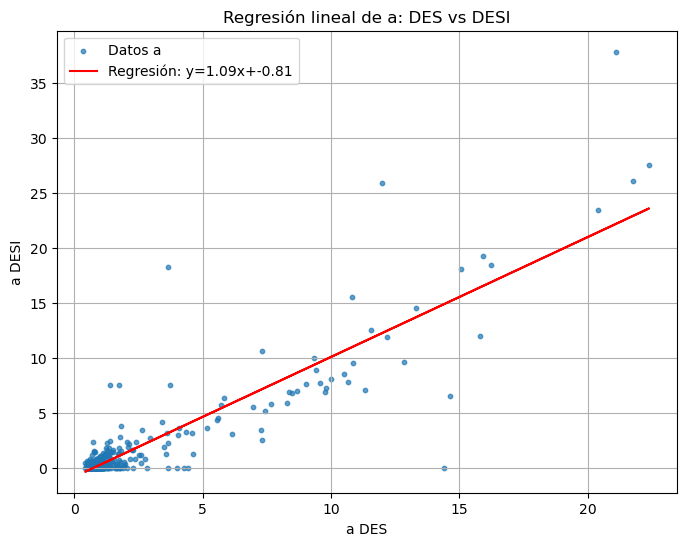

In [28]:
#Extraemos las columnas a de ambos surveys de los datos crossmatched
x = crossmatched_des_desi_0['DES_full_catalogue_Astrogeo_A_matches']*0.263
y = crossmatched_des_desi_0['a_axis']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos a')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('a DES')
plt.ylabel('a DESI')
plt.title('Regresión lineal de a: DES vs DESI')
plt.legend()
plt.grid(True)
plt.show()

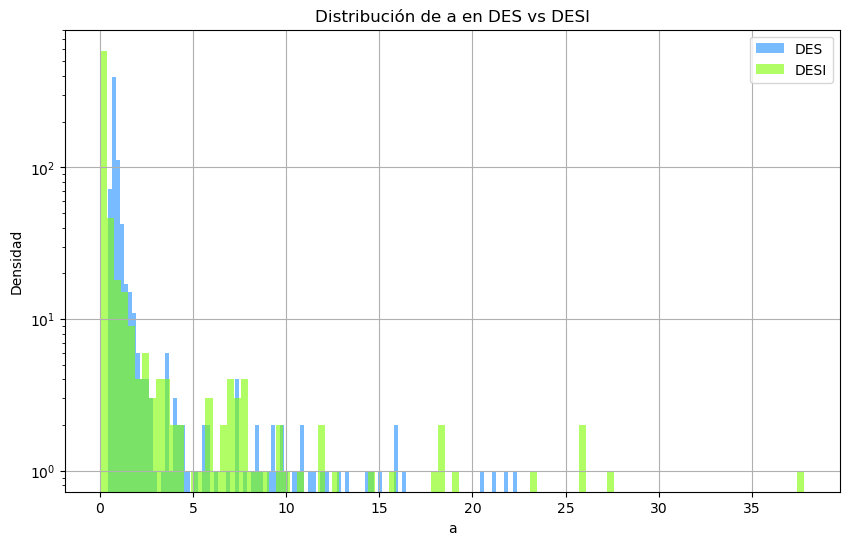

In [29]:
#Histograma de los a
plt.figure(figsize=(10, 6))
plt.hist(crossmatched_des_desi_0['DES_full_catalogue_Astrogeo_A_matches']*0.263, bins=100, color='dodgerblue', alpha=0.6, label='DES')
plt.hist(crossmatched_des_desi_0['a_axis'], bins=100, color='lawngreen', alpha=0.6, label='DESI')
plt.yscale('log')
plt.xlabel('a')
plt.ylabel('Densidad')
plt.title('Distribución de a en DES vs DESI')
plt.legend()
plt.grid(True)
plt.show()

##### a DES (filtrado) vs a DESI (sin filtrar)

Regresión lineal: y = 0.9106*x + -0.3934
Coeficiente de correlación (r): 0.8657
Error estándar: 0.0328
p-valor: 1.6528e-79


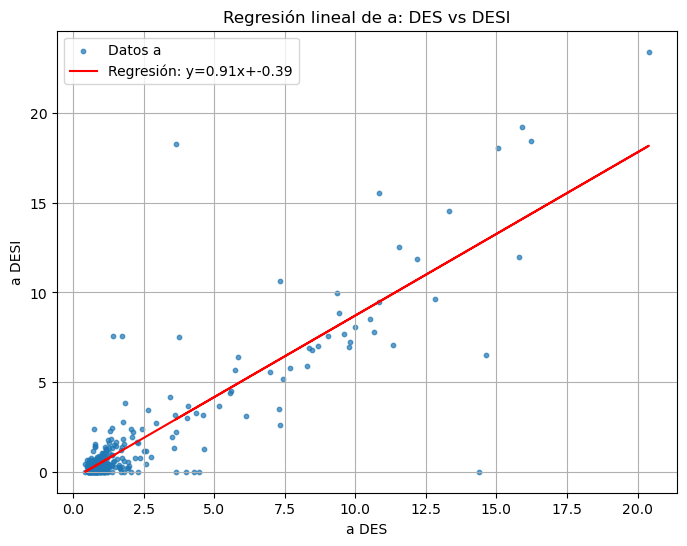

In [30]:
#Extraemos las columnas a de ambos surveys de los datos crossmatched
x = crossmatched_des_desi_1['DES_full_catalogue_Astrogeo_A_matches']*0.263
y = crossmatched_des_desi_1['a_axis']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos a')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('a DES')
plt.ylabel('a DESI')
plt.title('Regresión lineal de a: DES vs DESI')
plt.legend()
plt.grid(True)
plt.show()

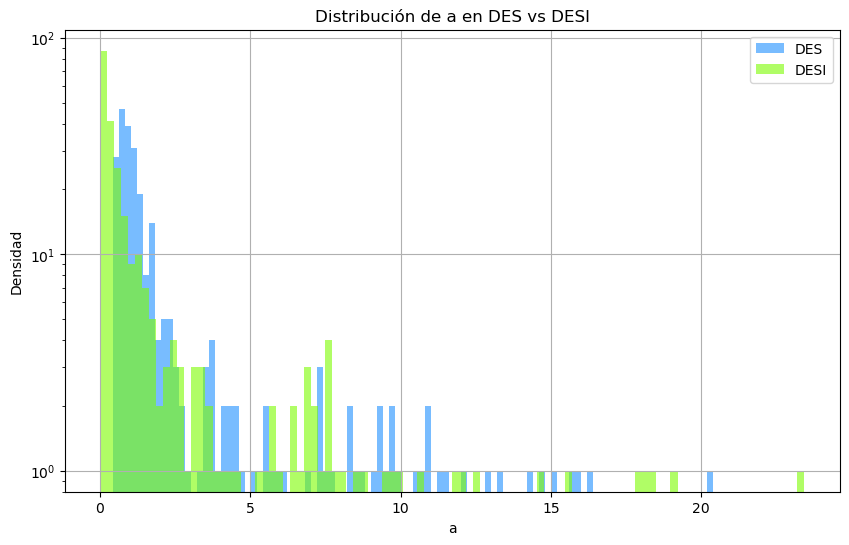

In [31]:
#Histograma de los a
plt.figure(figsize=(10, 6))
plt.hist(crossmatched_des_desi_1['DES_full_catalogue_Astrogeo_A_matches']*0.263, bins=100, color='dodgerblue', alpha=0.6, label='DES')
plt.hist(crossmatched_des_desi_1['a_axis'], bins=100, color='lawngreen', alpha=0.6, label='DESI')
plt.yscale('log')
plt.xlabel('a')
plt.ylabel('Densidad')
plt.title('Distribución de a en DES vs DESI')
plt.legend()
plt.grid(True)
plt.show()

##### a DES (sin filtrar) vs a DESI (filtrado)

Regresión lineal: y = 1.1212*x + -0.6098
Coeficiente de correlación (r): 0.8914
Error estándar: 0.0475
p-valor: 2.3879e-51


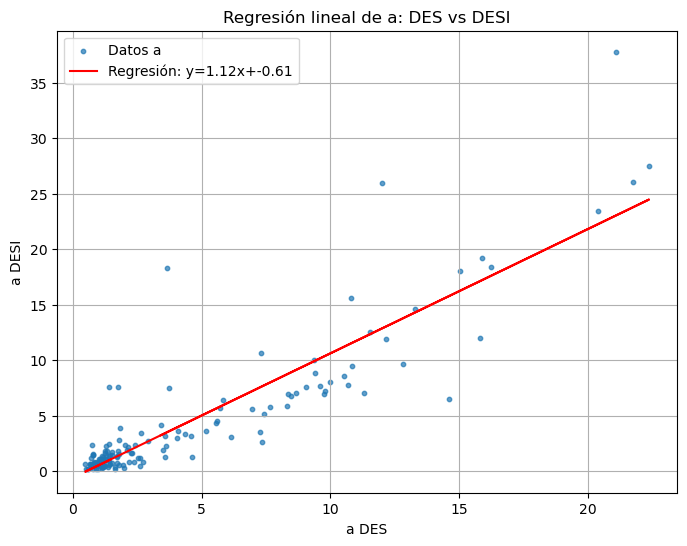

In [32]:
#Extraemos las columnas a de ambos surveys de los datos crossmatched
x = crossmatched_des_desi_2['DES_full_catalogue_Astrogeo_A_matches']*0.263
y = crossmatched_des_desi_2['a_axis']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos a')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('a DES')
plt.ylabel('a DESI')
plt.title('Regresión lineal de a: DES vs DESI')
plt.legend()
plt.grid(True)
plt.show()

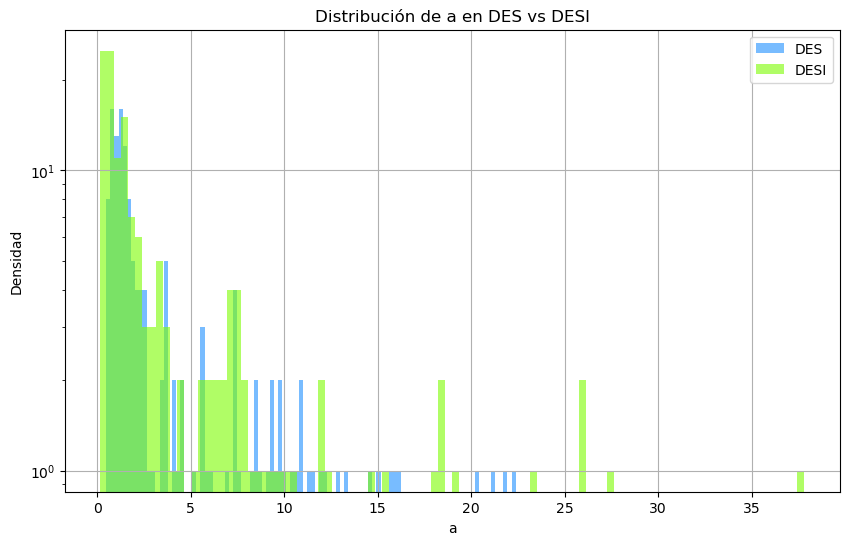

In [33]:
#Histograma de los a
plt.figure(figsize=(10, 6))
plt.hist(crossmatched_des_desi_2['DES_full_catalogue_Astrogeo_A_matches']*0.263, bins=100, color='dodgerblue', alpha=0.6, label='DES')
plt.hist(crossmatched_des_desi_2['a_axis'], bins=100, color='lawngreen', alpha=0.6, label='DESI')
plt.yscale('log')
plt.xlabel('a')
plt.ylabel('Densidad')
plt.title('Distribución de a en DES vs DESI')
plt.legend()
plt.grid(True)
plt.show()

##### a DES (filtrado) vs a DESI (filtrado)

Regresión lineal: y = 0.9359*x + -0.1033
Coeficiente de correlación (r): 0.8778
Error estándar: 0.0439
p-valor: 5.3902e-45


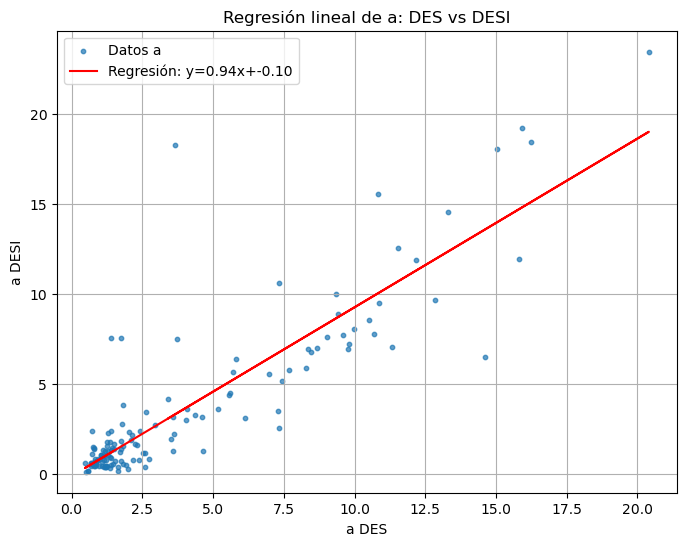

In [34]:
#Extraemos las columnas a de ambos surveys de los datos crossmatched
x = crossmatched_des_desi_3['DES_full_catalogue_Astrogeo_A_matches']*0.263
y = crossmatched_des_desi_3['a_axis']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos a')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('a DES')
plt.ylabel('a DESI')
plt.title('Regresión lineal de a: DES vs DESI')
plt.legend()
plt.grid(True)
plt.show()

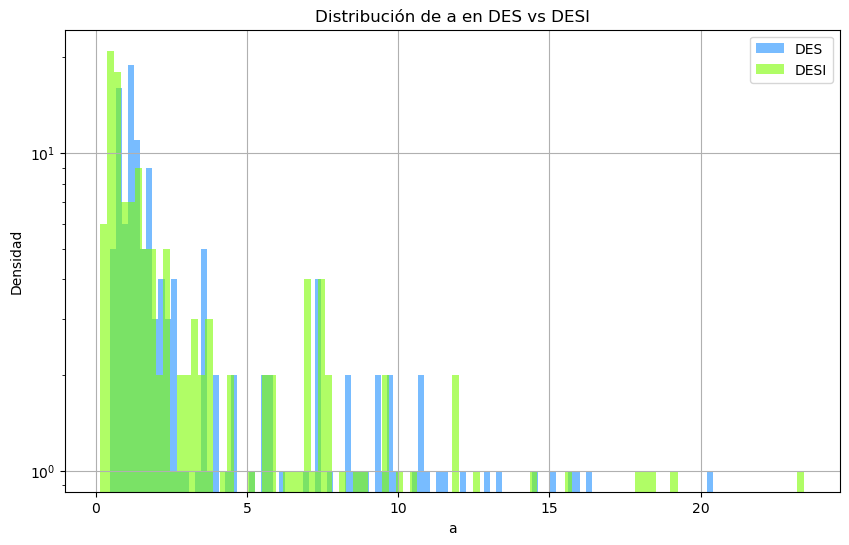

In [35]:
#Histograma de los a
plt.figure(figsize=(10, 6))
plt.hist(crossmatched_des_desi_3['DES_full_catalogue_Astrogeo_A_matches']*0.263, bins=100, color='dodgerblue', alpha=0.6, label='DES')
plt.hist(crossmatched_des_desi_3['a_axis'], bins=100, color='lawngreen', alpha=0.6, label='DESI')
plt.yscale('log')
plt.xlabel('a')
plt.ylabel('Densidad')
plt.title('Distribución de a en DES vs DESI')
plt.legend()
plt.grid(True)
plt.show()

#### b DES VS b DESI

##### b DES (sin filtrar) vs b DESI (sin filtrar)

Regresión lineal: y = 1.3220*x + -0.8190
Coeficiente de correlación (r): 0.8998
Error estándar: 0.0236
p-valor: 4.0253e-268


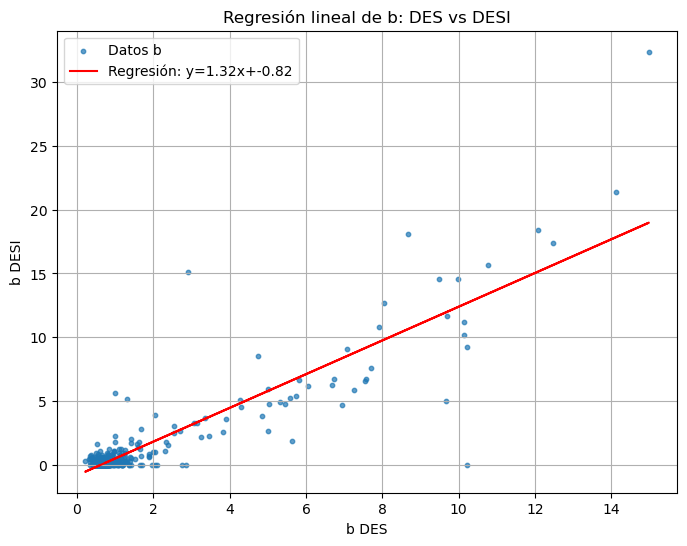

In [36]:
#Extraemos las columnas e1 de ambos surveys de los datos crossmatched
x = crossmatched_des_desi_0['DES_full_catalogue_Astrogeo_B_matches']*0.236
y = crossmatched_des_desi_0['b_axis']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos b')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('b DES')
plt.ylabel('b DESI')
plt.title('Regresión lineal de b: DES vs DESI')
plt.legend()
plt.grid(True)
plt.show()

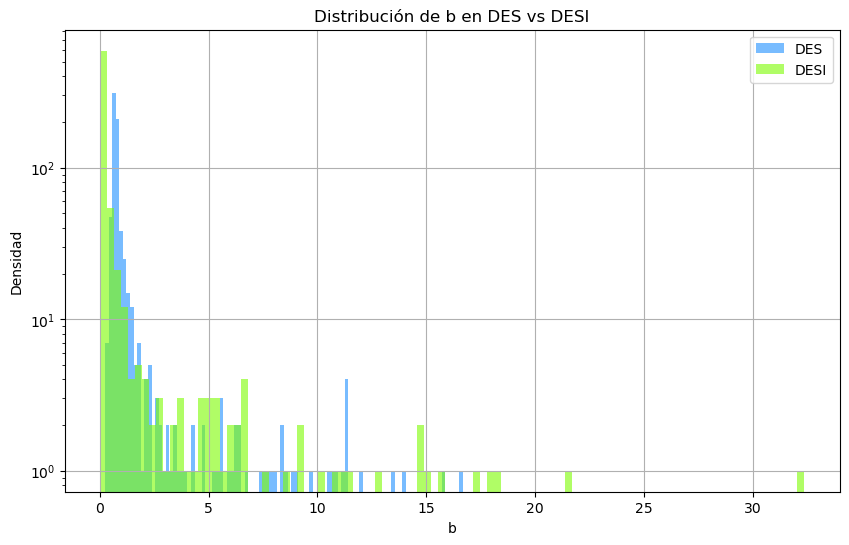

In [37]:
#Histograma de los b
plt.figure(figsize=(10, 6))
plt.hist(crossmatched_des_desi_0['DES_full_catalogue_Astrogeo_B_matches']*0.263, bins=100, color='dodgerblue', alpha=0.6, label='DES')
plt.hist(crossmatched_des_desi_0['b_axis'], bins=100, color='lawngreen', alpha=0.6, label='DESI')
plt.yscale('log')
plt.xlabel('b')
plt.ylabel('Densidad')
plt.title('Distribución de b en DES vs DESI')
plt.legend()
plt.grid(True)
plt.show()

##### b DES (filtrado) vs b DESI (sin filtrar)

Regresión lineal: y = 1.0026*x + -0.4606
Coeficiente de correlación (r): 0.8726
Error estándar: 0.0349
p-valor: 2.7977e-82


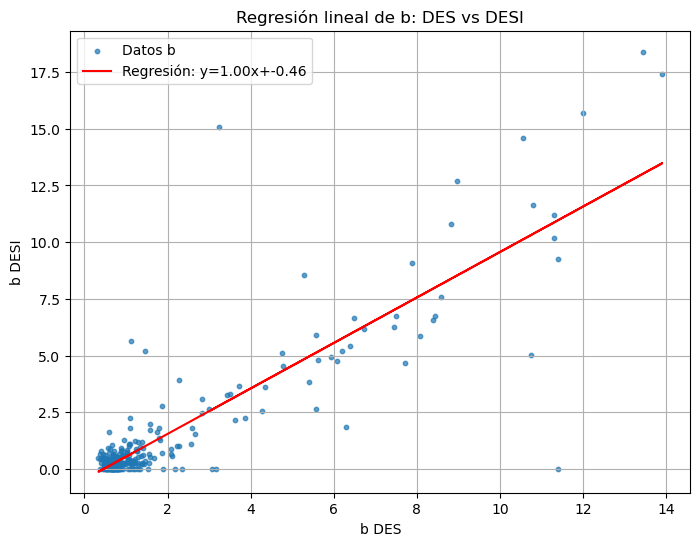

In [38]:
#Extraemos las columnas b de ambos surveys de los datos crossmatched
x = crossmatched_des_desi_1['DES_full_catalogue_Astrogeo_B_matches']*0.263
y = crossmatched_des_desi_1['b_axis']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos b')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('b DES')
plt.ylabel('b DESI')
plt.title('Regresión lineal de b: DES vs DESI')
plt.legend()
plt.grid(True)
plt.show()

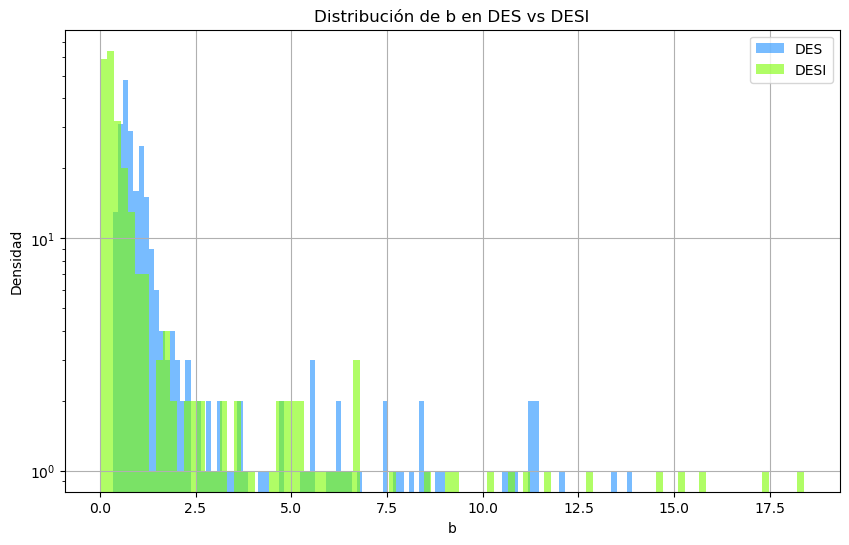

In [39]:
#Histograma de los b
plt.figure(figsize=(10, 6))
plt.hist(crossmatched_des_desi_1['DES_full_catalogue_Astrogeo_B_matches']*0.263, bins=100, color='dodgerblue', alpha=0.6, label='DES')
plt.hist(crossmatched_des_desi_1['b_axis'], bins=100, color='lawngreen', alpha=0.6, label='DESI')
plt.yscale('log')
plt.xlabel('b')
plt.ylabel('Densidad')
plt.title('Distribución de b en DES vs DESI')
plt.legend()
plt.grid(True)
plt.show()

##### b DES (sin filtrar) vs b DESI (filtrado)

Regresión lineal: y = 1.2359*x + -0.7515
Coeficiente de correlación (r): 0.9003
Error estándar: 0.0498
p-valor: 6.9137e-54


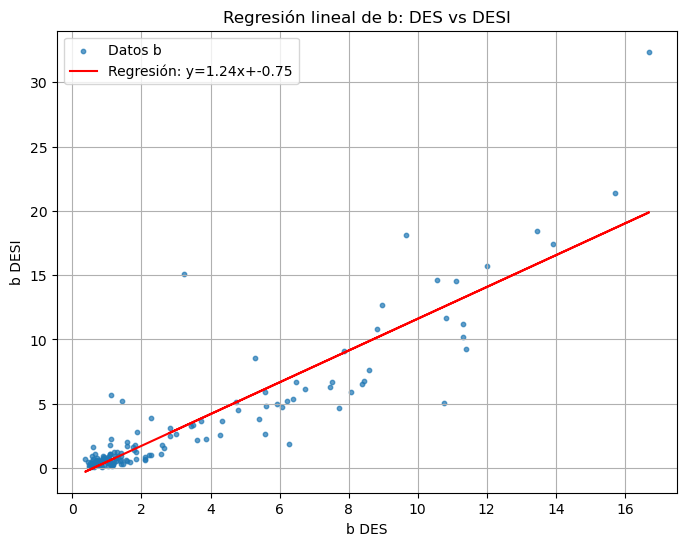

In [40]:
#Extraemos las columnas b de ambos surveys de los datos crossmatched
x = crossmatched_des_desi_2['DES_full_catalogue_Astrogeo_B_matches']*0.263
y = crossmatched_des_desi_2['b_axis']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos b')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('b DES')
plt.ylabel('b DESI')
plt.title('Regresión lineal de b: DES vs DESI')
plt.legend()
plt.grid(True)
plt.show()

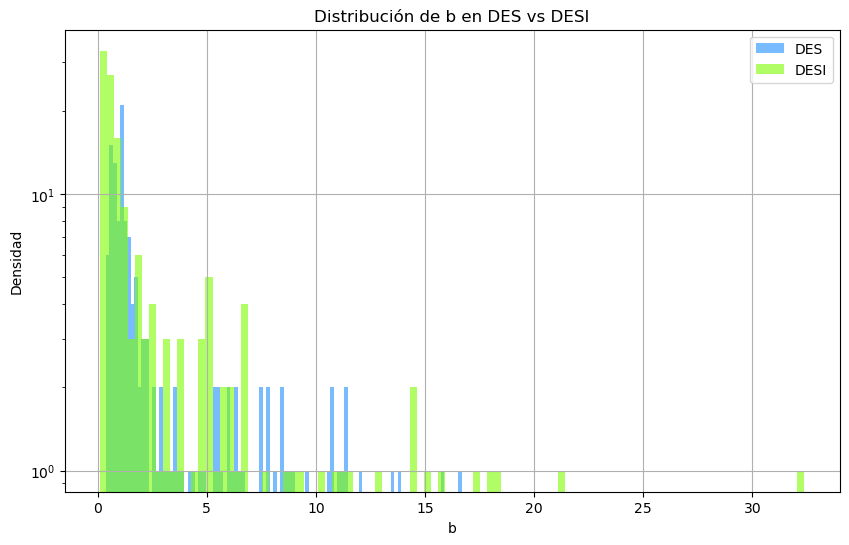

In [41]:
#Histograma de los b
plt.figure(figsize=(10, 6))
plt.hist(crossmatched_des_desi_2['DES_full_catalogue_Astrogeo_B_matches']*0.263, bins=100, color='dodgerblue', alpha=0.6, label='DES')
plt.hist(crossmatched_des_desi_2['b_axis'], bins=100, color='lawngreen', alpha=0.6, label='DESI')
plt.yscale('log')
plt.xlabel('b')
plt.ylabel('Densidad')
plt.title('Distribución de b en DES vs DESI')
plt.legend()
plt.grid(True)
plt.show()

##### b DES (filtrado) vs b DESI (filtrado)

Regresión lineal: y = 1.0499*x + -0.3566
Coeficiente de correlación (r): 0.8903
Error estándar: 0.0462
p-valor: 5.8850e-48


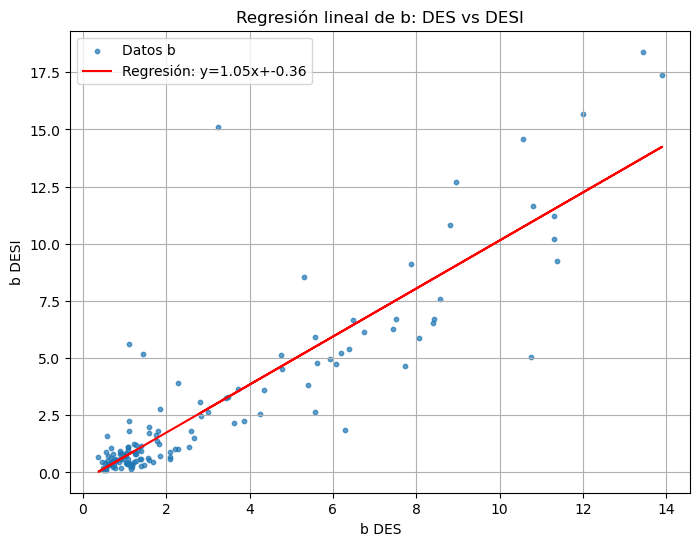

In [42]:
#Extraemos las columnas b de ambos surveys de los datos crossmatched
x = crossmatched_des_desi_3['DES_full_catalogue_Astrogeo_B_matches']*0.263
y = crossmatched_des_desi_3['b_axis']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos b')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('b DES')
plt.ylabel('b DESI')
plt.title('Regresión lineal de b: DES vs DESI')
plt.legend()
plt.grid(True)
plt.show()

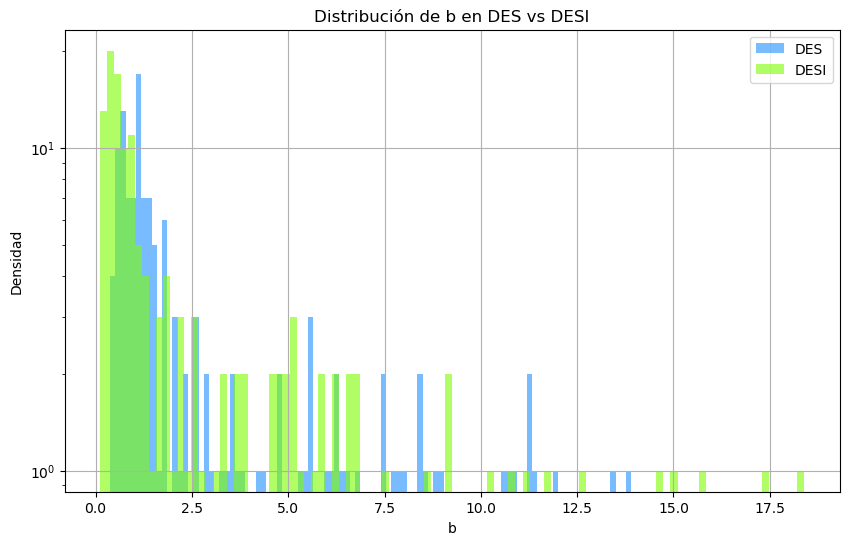

In [43]:
#Histograma de los b
plt.figure(figsize=(10, 6))
plt.hist(crossmatched_des_desi_3['DES_full_catalogue_Astrogeo_B_matches']*0.263, bins=100, color='dodgerblue', alpha=0.6, label='DES')
plt.hist(crossmatched_des_desi_3['b_axis'], bins=100, color='lawngreen', alpha=0.6, label='DESI')
plt.yscale('log')
plt.xlabel('b')
plt.ylabel('Densidad')
plt.title('Distribución de b en DES vs DESI')
plt.legend()
plt.grid(True)
plt.show()

### ESTUDIO DE LAS ELIPSES

In [44]:
from matplotlib.patches import Ellipse
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

#### Elipse DES VS DESI

A continuación, vamos a realizar el estudio de las elipses. Lo más lógico es utilizar los cross-matches de ambos surveys filtrados, ya que se tratan de las que son galaxias y, por tanto, tienen valores de los ejes no nulos. Debido a que DES tiene errores muy altos en los PA vamos a intentar dibujar el error en una gráfica y ver si se superpone con la elipse de DESI.

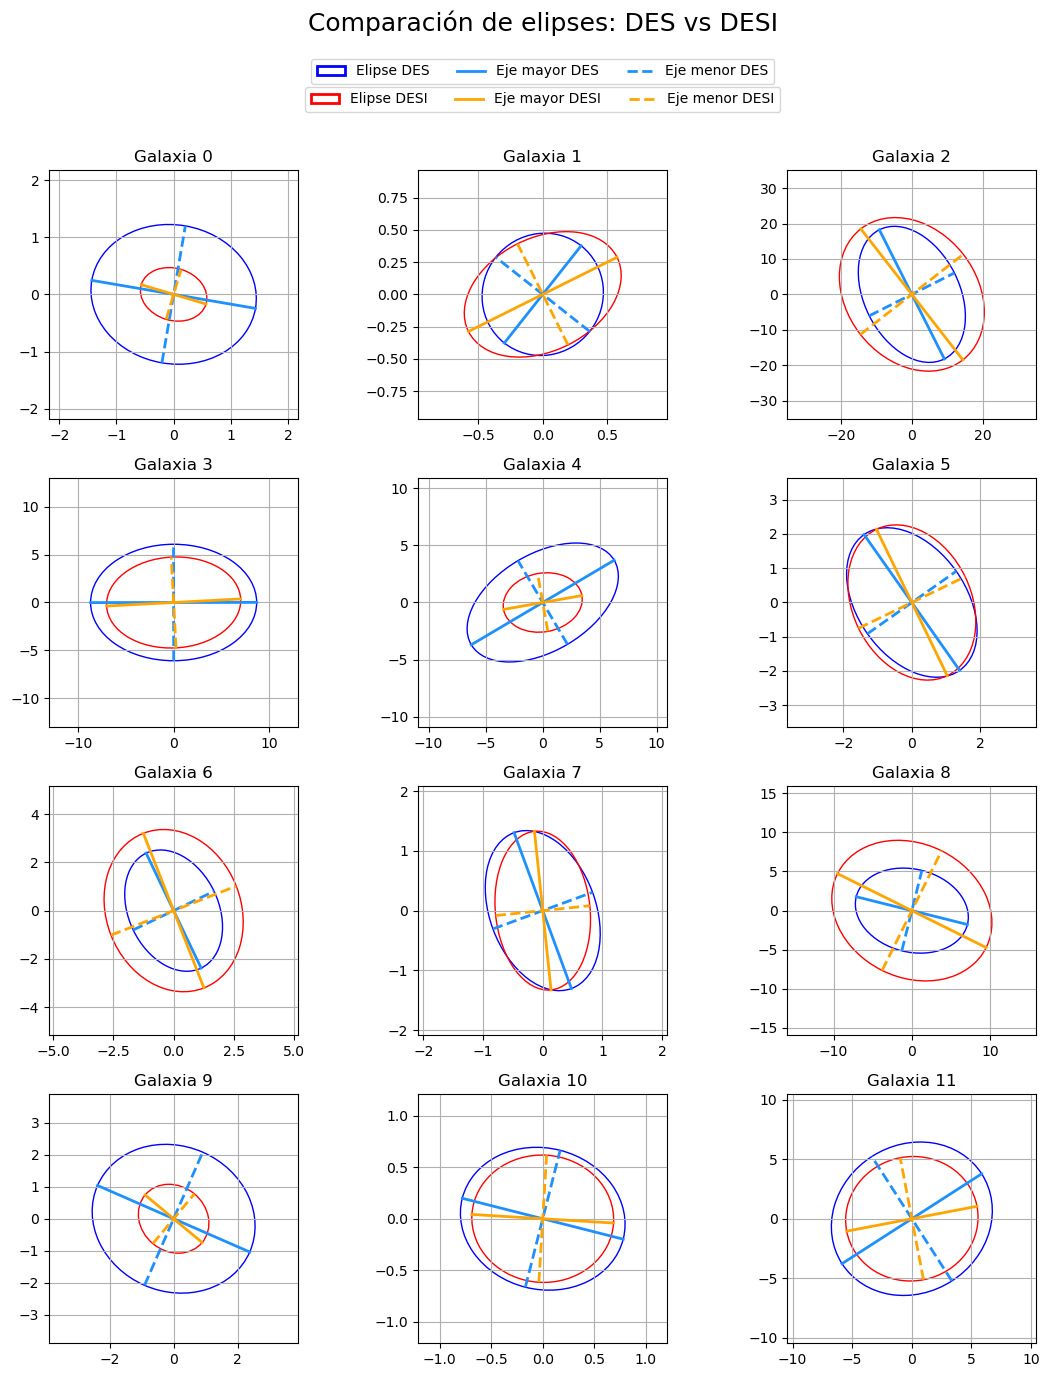

In [45]:
#Índices de las galaxias que queremos dibujar
indices = range(12)

#Creamos la figura con subplots
fig, axes = plt.subplots(4, 3, figsize=(12, 14))
axes = axes.flatten()

#Hacemos una función para dibujar ejes de la elipse
def dibujar_ejes(ax, a, b, PA, color):
    #Convertimos el ángulo a radianes
    theta = np.deg2rad(PA)

    #Vector eje mayor
    dx_major = a*np.cos(theta)
    dy_major = a*np.sin(theta)
    
    #Vector eje menor
    dx_minor = -b*np.sin(theta)
    dy_minor = b*np.cos(theta)
    
    #Centro
    x0, y0 = 0, 0
    
    #Dibujamos el eje mayor
    ax.plot([x0 - dx_major, x0 + dx_major], [y0 - dy_major, y0 + dy_major], color=color, linestyle='-', linewidth=2, label=f'Eje mayor')
    
    #Dibujamos el eje menor
    ax.plot([x0 - dx_minor, x0 + dx_minor], [y0 - dy_minor, y0 + dy_minor], color=color, linestyle='--', linewidth=2, label=f'Eje menor')

#Hacemos un bucle para dibujar las galaxias
for ax, index in zip(axes, indices):

    #Valores de DES
    a_DES = crossmatched_des_desi_3.loc[index, 'DES_full_catalogue_Astrogeo_A_matches']*0.263
    b_DES = crossmatched_des_desi_3.loc[index, 'DES_full_catalogue_Astrogeo_B_matches']*0.263
    PA_DES = crossmatched_des_desi_3.loc[index, 'DES_full_catalogue_Astrogeo_THETA_J2000_matches']

    #Valores de DESI
    a_DESI = crossmatched_des_desi_3.loc[index, 'a_axis']
    b_DESI = crossmatched_des_desi_3.loc[index, 'b_axis']
    PA_DESI = crossmatched_des_desi_3.loc[index, 'pos_angle']

    #Dibujamos las elipses
    el_DES = Ellipse((0, 0), 2*a_DES, 2*b_DES, angle=PA_DES, edgecolor='blue', facecolor='none')
    el_DESI = Ellipse((0, 0), 2*a_DESI, 2*b_DESI, angle=PA_DESI, edgecolor='red', facecolor='none')

    ax.add_patch(el_DES)
    ax.add_patch(el_DESI)

    #Dibujamos los ejes
    dibujar_ejes(ax, a_DES, b_DES, PA_DES, 'dodgerblue')
    dibujar_ejes(ax, a_DESI, b_DESI, PA_DESI, 'orange')

    #Configuración de la gráfica
    max_range = max(a_DES, b_DES, a_DESI, b_DESI)*1.5
    ax.set_xlim(-max_range, max_range)
    ax.set_ylim(-max_range, max_range)
    ax.set_aspect('equal')
    ax.set_title(f'Galaxia {index}')
    ax.grid(True)

#Leyenda
handles_DES = [Ellipse((0, 0), 1.0, 0.6, edgecolor='blue', facecolor='none', linewidth=2, label='Elipse DES'),
    Line2D([0], [0], color='dodgerblue', lw=2, linestyle='-', label='Eje mayor DES'),
    Line2D([0], [0], color='dodgerblue', lw=2, linestyle='--',label='Eje menor DES')]

handles_DESI = [Ellipse((0, 0), 1.0, 0.6, edgecolor='red', facecolor='none', linewidth=2, label='Elipse DESI'),
    Line2D([0], [0], color='orange', lw=2, linestyle='-', label='Eje mayor DESI'),
    Line2D([0], [0], color='orange', lw=2, linestyle='--', label='Eje menor DESI')]

plt.tight_layout(rect=[0, 0, 1, 0.85])
fig.legend(handles=handles_DES, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 0.95))
fig.legend(handles=handles_DESI, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 0.93))

fig.suptitle('Comparación de elipses: DES vs DESI', fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

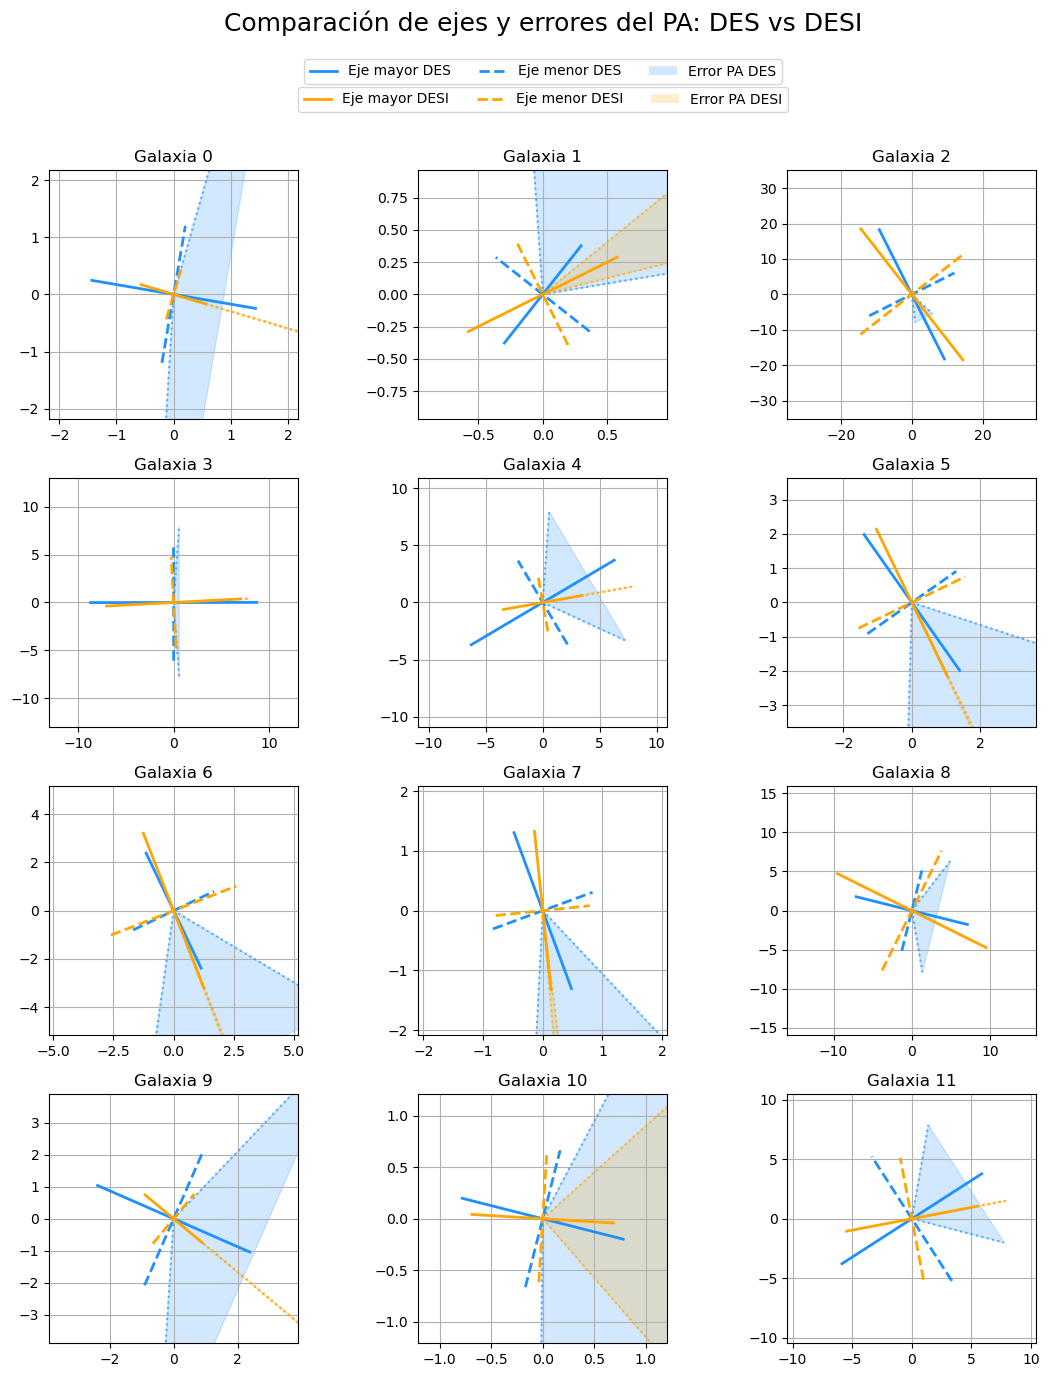

In [46]:
#Índices de las galaxias que queremos dibujar
indices = range(12)

#Creamos la figura con subplots
fig, axes = plt.subplots(4, 3, figsize=(12, 14))
axes = axes.flatten()

#Hacemos una función para dibujar ejes de la elipse
def dibujar_ejes(ax, a, b, PA, color):
    #Convertimos el ángulo a radianes
    theta = np.deg2rad(PA)

    #Vector eje mayor
    dx_major = a*np.cos(theta)
    dy_major = a*np.sin(theta)
    
    #Vector eje menor
    dx_minor = -b*np.sin(theta)
    dy_minor = b*np.cos(theta)
    
    #Centro
    x0, y0 = 0, 0
    
    #Dibujamos el eje mayor
    ax.plot([x0 - dx_major, x0 + dx_major], [y0 - dy_major, y0 + dy_major], color=color, linestyle='-', linewidth=2, label=f'Eje mayor')
    
    #Dibujamos el eje menor
    ax.plot([x0 - dx_minor, x0 + dx_minor], [y0 - dy_minor, y0 + dy_minor], color=color, linestyle='--', linewidth=2, label=f'Eje menor')

#Hacemos una función para dibujar los errores del PA
def dibujar_error_PA(ax, PA, PA_err, color, r=8): #ponemos r=8 para comparar las PA a la misma escala
    x0, y0 = 0, 0
    
    theta_plus = np.deg2rad(PA + PA_err)
    theta_minus = np.deg2rad(PA - PA_err)

    #Vectores para los ángulos con error
    dx_p = r*np.cos(theta_plus)
    dy_p = r*np.sin(theta_plus)
    dx_m = r*np.cos(theta_minus)
    dy_m = r*np.sin(theta_minus)

    #Dibujamos las líneas
    ax.plot([x0, dx_p], [y0, dy_p], color=color, linestyle=":", alpha=0.7)
    ax.plot([x0, dx_m], [y0, dy_m], color=color, linestyle=":", alpha=0.7)
    
    #Rellenamos el abanico del error
    ax.fill([x0, dx_p, dx_m], [y0, dy_p, dy_m], color=color, alpha=0.2, label="Error PA")

#Hacemos un bucle para dibujar las galaxias
for ax, index in zip(axes, indices):

    #Valores de DES
    a_DES = crossmatched_des_desi_3.loc[index, 'DES_full_catalogue_Astrogeo_A_matches']*0.263
    b_DES = crossmatched_des_desi_3.loc[index, 'DES_full_catalogue_Astrogeo_B_matches']*0.263
    PA_DES = crossmatched_des_desi_3.loc[index, 'DES_full_catalogue_Astrogeo_THETA_J2000_matches']
    PA_err_DES = crossmatched_des_desi_3.loc[index, 'DES_full_catalogue_Astrogeo_ERRTHETA_IMAGE_matches']

    #Valores de DESI
    a_DESI = crossmatched_des_desi_3.loc[index, 'a_axis']
    b_DESI = crossmatched_des_desi_3.loc[index, 'b_axis']
    PA_DESI = crossmatched_des_desi_3.loc[index, 'pos_angle']
    PA_err_DESI = crossmatched_des_desi_3.loc[index, 'pos_angle_err']

    #Dibujamos los ejes y los errores
    dibujar_ejes(ax, a_DES, b_DES, PA_DES, 'dodgerblue')
    dibujar_error_PA(ax, PA_DES, PA_err_DES, 'dodgerblue', r=8)
    
    dibujar_ejes(ax, a_DESI, b_DESI, PA_DESI, 'orange')
    dibujar_error_PA(ax, PA_DESI, PA_err_DESI, 'orange', r=8)

    #Configuración de la gráfica
    max_range = max(a_DES, b_DES, a_DESI, b_DESI)*1.5
    ax.set_xlim(-max_range, max_range)
    ax.set_ylim(-max_range, max_range)
    ax.set_aspect('equal')
    ax.set_title(f'Galaxia {index}')
    ax.grid(True)

#Leyenda
handles_DES = [Line2D([0], [0], color='dodgerblue', lw=2, linestyle='-', label='Eje mayor DES'),
    Line2D([0], [0], color='dodgerblue', lw=2, linestyle='--', label='Eje menor DES'),
    Patch(facecolor='dodgerblue', alpha=0.2, label='Error PA DES')]

handles_DESI = [Line2D([0], [0], color='orange', lw=2, linestyle='-', label='Eje mayor DESI'),
    Line2D([0], [0], color='orange', lw=2, linestyle='--', label='Eje menor DESI'),
    Patch(facecolor='orange', alpha=0.2, label='Error PA DESI')]

plt.tight_layout(rect=[0, 0, 1, 0.85])
fig.legend(handles=handles_DES, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 0.95))
fig.legend(handles=handles_DESI, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 0.93))

fig.suptitle('Comparación de ejes y errores del PA: DES vs DESI', fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

Por otro lado, vamos a realizar la compraración de las elipticidades calculadas de DESI con las que ya vienen en DESI. También compararemos, las calculadas de DES con las calculadas de DESI.

In [47]:
#Función para determinar las elipticidades
def elipticidad(a, b, PA):
    q = b/a
    e = (1 - q)/(1 + q)
    theta = np.deg2rad(PA)
    e1 = e*np.cos(2*theta)
    e2 = e*np.sin(2*theta)
    return e1, e2

In [48]:
crossmatched_des_desi_3['e1_des'], crossmatched_des_desi_3['e2_des'] = zip(*crossmatched_des_desi_3.apply(
    lambda row: elipticidad(row['DES_full_catalogue_Astrogeo_A_matches']*0.263,
                             row['DES_full_catalogue_Astrogeo_B_matches']*0.263,
                             row['DES_full_catalogue_Astrogeo_THETA_J2000_matches']), axis=1))

crossmatched_des_desi_3['e1_desi'], crossmatched_des_desi_3['e2_desi'] = zip(*crossmatched_des_desi_3.apply(
    lambda row: elipticidad(row['a_axis'],
                             row['b_axis'],
                             row['pos_angle']), axis=1))

Regresión lineal: y = 1.0000*x + 0.0000
Coeficiente de correlación (r): 1.0000
Error estándar: 0.0000
p-valor: 0.0000e+00


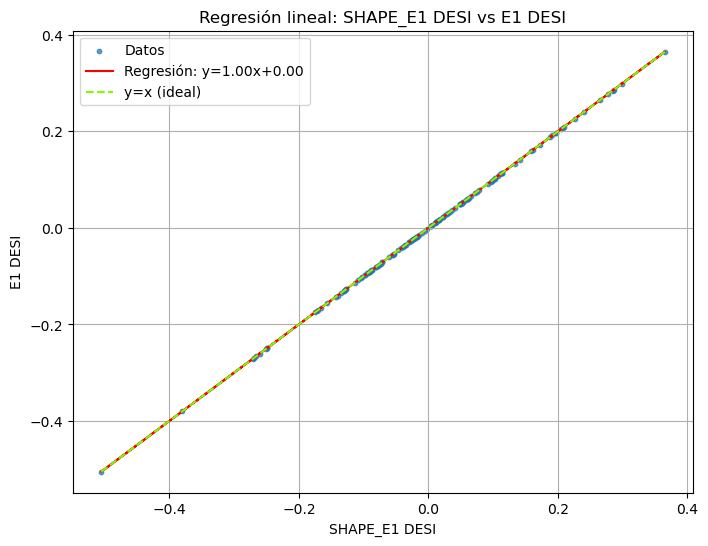

In [49]:
#Hacemos una regresión lineal para ver mejor la diferencia
x = crossmatched_des_desi_3['SHAPE_E1']
y = crossmatched_des_desi_3['e1_desi']

#Ajuste lineal
slope, intercept, r_value, p_value, std_err = linregress(x, y)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos el scatter y la recta ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x, y, s=10, alpha=0.7, label='Datos')
plt.plot(x, slope * x + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')
plt.plot([min(x), max(x)], [min(x), max(x)], color='lawngreen', linestyle='--', label='y=x (ideal)')
plt.xlabel('SHAPE_E1 DESI')
plt.ylabel('E1 DESI')
plt.title('Regresión lineal: SHAPE_E1 DESI vs E1 DESI')
plt.grid(True)
plt.legend()
plt.show()

Regresión lineal: y = 0.6196*x + -0.0012
Coeficiente de correlación (r): 0.8079
Error estándar: 0.0389
p-valor: 8.5260e-33


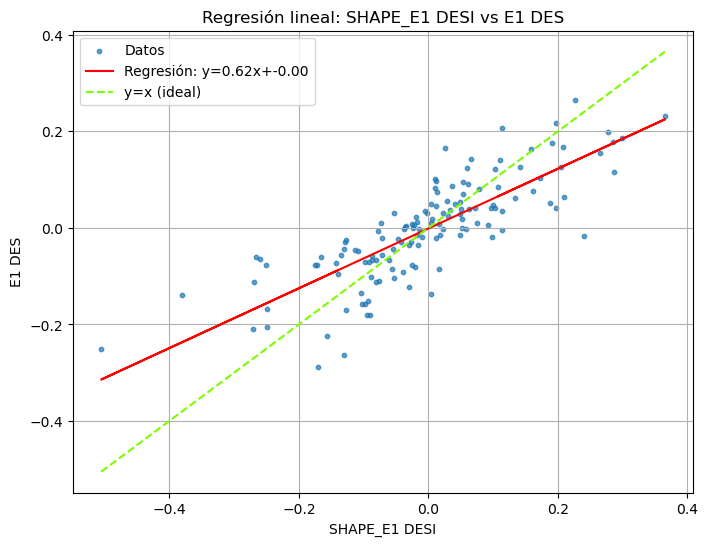

In [50]:
#Hacemos una regresión lineal para ver mejor la diferencia
x = crossmatched_des_desi_3['SHAPE_E1']
y = crossmatched_des_desi_3['e1_des']

#Ajuste lineal
slope, intercept, r_value, p_value, std_err = linregress(x, y)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos el scatter y la recta ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x, y, s=10, alpha=0.7, label='Datos')
plt.plot(x, slope*x + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')
plt.plot([min(x), max(x)], [min(x), max(x)], color='lawngreen', linestyle='--', label='y=x (ideal)')
plt.xlabel('SHAPE_E1 DESI')
plt.ylabel('E1 DES')
plt.title('Regresión lineal: SHAPE_E1 DESI vs E1 DES')
plt.grid(True)
plt.legend()
plt.show()

Regresión lineal: y = 1.0000*x + -0.0000
Coeficiente de correlación (r): 1.0000
Error estándar: 0.0000
p-valor: 0.0000e+00


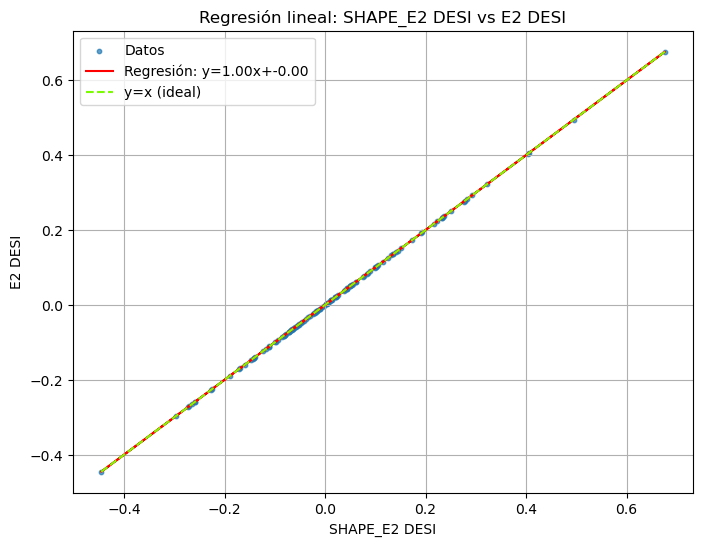

In [51]:
#Hacemos una regresión lineal para ver mejor la diferencia
x = crossmatched_des_desi_3['SHAPE_E2']
y = crossmatched_des_desi_3['e2_desi']

#Ajuste lineal
slope, intercept, r_value, p_value, std_err = linregress(x, y)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos el scatter y la recta ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x, y, s=10, alpha=0.7, label='Datos')
plt.plot(x, slope * x + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')
plt.plot([min(x), max(x)], [min(x), max(x)], color='lawngreen', linestyle='--', label='y=x (ideal)')
plt.xlabel('SHAPE_E2 DESI')
plt.ylabel('E2 DESI')
plt.title('Regresión lineal: SHAPE_E2 DESI vs E2 DESI')
plt.grid(True)
plt.legend()
plt.show()

Regresión lineal: y = 0.4912*x + -0.0045
Coeficiente de correlación (r): 0.6856
Error estándar: 0.0449
p-valor: 2.4214e-20


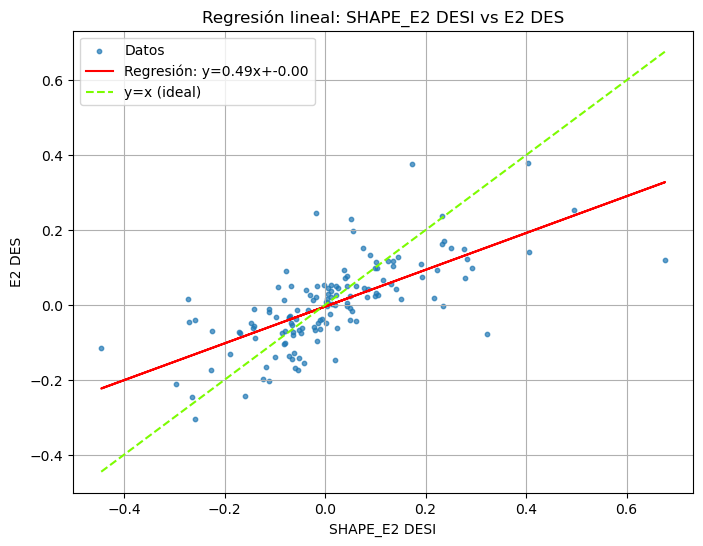

In [52]:
#Hacemos una regresión lineal para ver mejor la diferencia
x = crossmatched_des_desi_3['SHAPE_E2']
y = crossmatched_des_desi_3['e2_des']

#Ajuste lineal
slope, intercept, r_value, p_value, std_err = linregress(x, y)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos el scatter y la recta ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x, y, s=10, alpha=0.7, label='Datos')
plt.plot(x, slope*x + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')
plt.plot([min(x), max(x)], [min(x), max(x)], color='lawngreen', linestyle='--', label='y=x (ideal)')
plt.xlabel('SHAPE_E2 DESI')
plt.ylabel('E2 DES')
plt.title('Regresión lineal: SHAPE_E2 DESI vs E2 DES')
plt.grid(True)
plt.legend()
plt.show()

Regresión lineal: y = 0.3375*x + 0.5331
Coeficiente de correlación (r): 0.4515
Error estándar: 0.0574
p-valor: 3.0651e-08


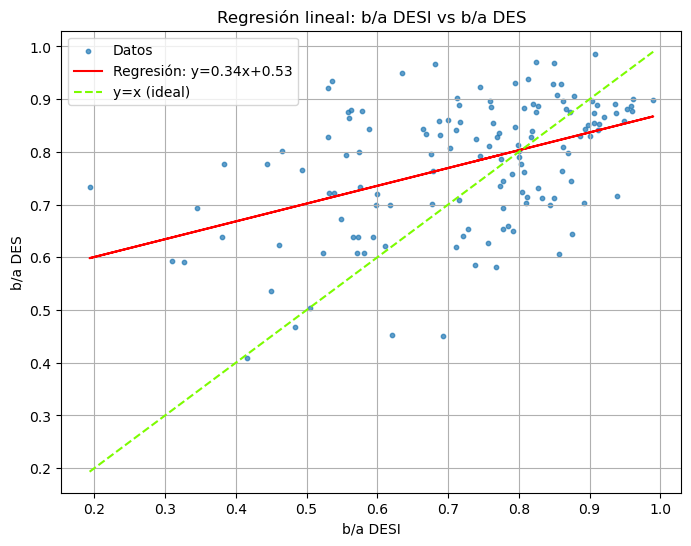

In [53]:
#Función para determinar la relación b/a
def ratio(a, b):
    q = b/a
    return q

crossmatched_des_desi_3['q_des'] = crossmatched_des_desi_3.apply(
    lambda row: ratio(row['DES_full_catalogue_Astrogeo_A_matches']*0.263,
                             row['DES_full_catalogue_Astrogeo_B_matches']*0.263), axis=1)

crossmatched_des_desi_3['q_desi'] = crossmatched_des_desi_3.apply(
    lambda row: ratio(row['a_axis'], row['b_axis']), axis=1)

#Hacemos una regresión lineal para ver mejor la diferencia
x = crossmatched_des_desi_3['q_desi']
y = crossmatched_des_desi_3['q_des']

#Ajuste lineal
slope, intercept, r_value, p_value, std_err = linregress(x, y)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos el scatter y la recta ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x, y, s=10, alpha=0.7, label='Datos')
plt.plot(x, slope * x + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')
plt.plot([min(x), max(x)], [min(x), max(x)], color='lawngreen', linestyle='--', label='y=x (ideal)')
plt.xlabel('b/a DESI')
plt.ylabel('b/a DES')
plt.title('Regresión lineal: b/a DESI vs b/a DES')
plt.grid(True)
plt.legend()
plt.show()